In [ ]:
!pip install py-pde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.4/370.4 kB 12.0 MB/s eta 0:00:00


In [ ]:
import pickle
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pde
from pde import PDE, FieldCollection, ScalarField, UnitGrid, PlotTracker, CartesianGrid
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.interpolate import griddata

# DeepONet


In [ ]:
class MLP(nn.Module):
  def __init__(self, input_dim, hidden_dim, number_of_layers):
    super().__init__()

    self.activation = nn.Tanh()

    layers = []
    layers.append(nn.Linear(input_dim, hidden_dim))
    layers.append(self.activation)

    for _ in range(number_of_layers - 1):
      layers.append(nn.Linear(hidden_dim, hidden_dim))
      layers.append(self.activation)

    self.net = nn.Sequential(*layers)
    self.initialize_weights()

  def initialize_weights(self):
    for module in self.modules():
      if isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        nn.init.zeros_(module.bias)

  def forward(self, x):
    return self.net(x)

In [ ]:
class CNN3DEncoder(nn.Module):
    """CNN to process 3D spatial grid and output latent representation"""
    def __init__(self, in_channels, latent_dim, grid_size):
        super().__init__()

        # Assume grid_size is tuple (Nx, Ny, Nz) or single int
        if isinstance(grid_size, int):
            grid_size = (grid_size, grid_size, grid_size)

        self.latent_dim = latent_dim

        # 3D Convolutional layers
        self.conv_layers = nn.Sequential(
            # Layer 1: in_channels -> 32
            nn.Conv3d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            nn.MaxPool3d(2),  # Reduces spatial dims by 2

            # Layer 2: 32 -> 64
            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(),
            nn.MaxPool3d(2),  # Reduces spatial dims by 2 again

            # Layer 3: 64 -> 128
            nn.Conv3d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool3d(4)  # Adaptive pooling to fixed size
        )

        # Calculate flattened size after conv layers
        self.flatten_size = 128 * 4 * 4 * 4  # 128 channels * 4x4x4 spatial

        # Fully connected layers to get latent representation
        self.fc = nn.Sequential(
            nn.Linear(self.flatten_size, 512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, latent_dim)
        )

        self.initialize_weights()

    def initialize_weights(self):
        for module in self.modules():
            if isinstance(module, (nn.Conv3d, nn.Linear)):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x):
        # x shape: (batch_size, in_channels, Nx, Ny, Nz)
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc(x)
        return x  # (batch_size, latent_dim)

In [ ]:
class DeepONet(nn.Module):
    def __init__(self, hidden_dim = 128, output_dim = 4, number_of_layers = 3,
            grid_channels = 4, grid_size = 30, cnn_latent_dim=256):
        super().__init__()

        self.cnn_encoder = CNN3DEncoder(grid_channels, cnn_latent_dim, grid_size)
        self.branch = MLP(cnn_latent_dim, hidden_dim, number_of_layers)
        self.trunk = MLP(grid_channels, hidden_dim, number_of_layers)

        self.output_layers = nn.ModuleList([
            nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim // 2, 1)
            ) for _ in range(output_dim)
        ])

    def forward(self, grid_input, trunk_input):
        branch_input = self.cnn_encoder(grid_input)
        branch_output = self.branch(branch_input)

        # Expand branch output to match trunk input points
        batch_size = grid_input.size(0)
        n_points = trunk_input.size(0) // batch_size
        branch_output = branch_output.unsqueeze(1).repeat(1, n_points, 1)
        branch_output = branch_output.reshape(-1, branch_output.size(-1))

        trunk_output = self.trunk(trunk_input)

        combined_output = branch_output * trunk_output

        outputs = []
        for layer in self.output_layers:
            outputs.append(layer(combined_output))

        return torch.cat(outputs, dim =-1)

# system

In [ ]:
params = {
    # Equation 1 parameters (N equation)
    'r2': 1.0,      # Growth rate
    'b2': 0.81,     # Carrying capacity
    'c4': 1.0,      # Competition term
    'a3': 0.1,      # Fraction cell kill
    'D_N': 0,    # Diffusion coefficient (assumed)

    # Equation 2 parameters (T equation)
    'r1': 1.1,      # Growth rate
    'b1': 1.0,      # Carrying capacity
    'c2': 0.55,     # Competition term
    'c3': 0.9,      # Competition term
    'a2': 0.3,      # Fraction cell kill
    'D_T': 0.001,    # Diffusion coefficient (assumed)

    # Equation 3 parameters (I equation)
    's': 0.33,      # Immune source rate
    'rho': 0.2,     # Immune response rate
    'alpha': 0.3,   # Immune threshold rate
    'c1': 1.0,      # Competition term
    'd1': 0.2,      # Death rate
    'a1': 0.2,      # Fraction cell kill
    'D_I': 0.001,    # Diffusion coefficient (assumed)

    # Equation 4 parameters (U equation)
    'd2': 1.0,      # Death rate
    'D_U': 0.00,    # Diffusion coefficient (assumed)
    'v_func': lambda t: 0.0  # No treatment initially (modify as needed)
}

r2   = params["r2"]
b2   = params["b2"]
c4   = params["c4"]
a3   = params["a3"]

r1   = params["r1"]
b1   = params["b1"]
c2   = params["c2"]
c3   = params["c3"]
a2   = params["a2"]

s    = params["s"]
rho  = params["rho"]
alpha= params["alpha"]
c1   = params["c1"]
d1   = params["d1"]
a1   = params["a1"]

d2   = params["d2"]

DN   = params["D_N"]
DT   = params["D_T"]
DI   = params["D_I"]
DU   = params["D_U"]

In [ ]:
eq = PDE(
    {
        "N": f"{r2} * N * (1 - {b2} * N) - {c4} * T * N - {a3} * (1 - exp(-U)) * N + {DN} * laplace(N)",
        "T": f"{r1} * T * (1 - {b1} * T) - {c2} * I * T - {c3} * T * N - {a2} * (1 - exp(-U)) * T + {DT} * laplace(T)",
        "I": f"{s} + {rho} * I * T / ({alpha} + T) - {c1} * I * T - {d1} * I - {a1} * (1 - exp(-U)) * I + {DI} * laplace(I)",
        "U": f"0 - {d2} * U + {DU} * laplace(U)"
    }
)

# initialize state
grid = CartesianGrid([[-2, 2], [-2, 2], [-2,2]], 30)  # generate grid
N = ScalarField.from_expression(grid, "0.2 * exp(-2 * x**2)")
T = ScalarField.from_expression(grid, "1 - 0.75 * sech(x)")
I = ScalarField.from_expression(grid, "0.375 - 0.235 * (sech(x))**2")
U = ScalarField(grid)
state = FieldCollection(np.asarray([N, T, I, U]))
memoryStorage = pde.MemoryStorage()
# simulate the pde
plotTracker = PlotTracker()
sol = eq.solve(state, t_range=14, dt=1e-3, tracker=[plotTracker, memoryStorage.tracker()])

Output()

# Test

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from tqdm import tqdm

class PDEDataset(Dataset):
    def __init__(self, solutions, n_samples_per_ic=1000, train=True, train_split=0.8,
                 mean=None, std=None):
        """
        Dataset for PDE solutions with normalization
        """
        self.solutions = torch.FloatTensor(solutions)
        self.n_ics, self.n_times, self.n_outputs, self.x_num, self.y_num, self.z_num = solutions.shape
        self.n_samples_per_ic = n_samples_per_ic

        # Split ICs into train/val
        n_train_ics = int(self.n_ics * train_split)
        if train:
            self.ic_indices = list(range(n_train_ics))
        else:
            self.ic_indices = list(range(n_train_ics, self.n_ics))

        # Compute normalization statistics from training data
        if mean is None and train:
            train_data = solutions[:n_train_ics]
            self.mean = torch.FloatTensor(train_data.mean(axis=(0, 1, 3, 4, 5)))
            self.std = torch.FloatTensor(train_data.std(axis=(0, 1, 3, 4, 5))) + 1e-8
        else:
            self.mean = mean if mean is not None else torch.zeros(self.n_outputs)
            self.std = std if std is not None else torch.ones(self.n_outputs)

        # Create normalized coordinate grids
        self.t_grid = torch.linspace(0, 1, self.n_times)
        self.x_grid = torch.linspace(0, 1, self.x_num)
        self.y_grid = torch.linspace(0, 1, self.y_num)
        self.z_grid = torch.linspace(0, 1, self.z_num)

    def __len__(self):
        return len(self.ic_indices) * self.n_samples_per_ic

    def __getitem__(self, idx):
        ic_idx = self.ic_indices[idx // self.n_samples_per_ic]
        t_idx = np.random.randint(1, self.n_times)
        x_idx = np.random.randint(0, self.x_num)
        y_idx = np.random.randint(0, self.y_num)
        z_idx = np.random.randint(0, self.z_num)

        t = self.t_grid[t_idx]
        x = self.x_grid[x_idx]
        y = self.y_grid[y_idx]
        z = self.z_grid[z_idx]

        trunk_input = torch.tensor([t, x, y, z], dtype=torch.float32)
        ic_input = self.solutions[ic_idx, 0, :, :, :, :]
        target = self.solutions[ic_idx, t_idx, :, x_idx, y_idx, z_idx]

        # Normalize target
        target = (target - self.mean) / self.std

        return trunk_input, ic_input, target, ic_idx

def train_epoch(model, train_loader, optimizer, criterion, device, max_grad_norm=1.0):
    model.train()
    total_loss = 0
    n_batches = 0

    for trunk_input, ic_input, target, _ in tqdm(train_loader, desc="Training"):
        trunk_input = trunk_input.to(device)
        ic_input = ic_input.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        # FIX: Swapped arguments to model to match DeepONet.forward(grid_input, trunk_input)
        output = model(ic_input, trunk_input)

        loss = criterion(output, target)

        # Check for NaN
        if torch.isnan(loss):
            print("Warning: NaN loss detected, skipping batch")
            continue

        loss.backward()

        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    return total_loss / max(n_batches, 1)


def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    n_batches = 0

    with torch.no_grad():
        for trunk_input, ic_input, target, _ in val_loader:
            trunk_input = trunk_input.to(device)
            ic_input = ic_input.to(device)
            target = target.to(device)

            # FIX: Swapped arguments to model to match DeepONet.forward(grid_input, trunk_input)
            output = model(ic_input, trunk_input)
            loss = criterion(output, target)

            if not torch.isnan(loss):
                total_loss += loss.item()
                n_batches += 1

    return total_loss / max(n_batches, 1)


def train_model(solutions, hidden_dim=256, output_dim=4, number_of_layers=4,
                n_samples_per_ic=1000, batch_size=32, epochs=100, lr=5e-4, patience = 20,
                train_split=0.8, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Train the DeepONet model with improved hyperparameters
    """
    print(f"Solutions shape: {solutions.shape}")
    print(f"Using device: {device}")

    # Create datasets with normalization
    train_dataset = PDEDataset(solutions, n_samples_per_ic=n_samples_per_ic,
                               train=True, train_split=train_split)
    val_dataset = PDEDataset(solutions, n_samples_per_ic=n_samples_per_ic//2,
                             train=False, train_split=train_split,
                             mean=train_dataset.mean, std=train_dataset.std)

    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                             shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size,
                           shuffle=False, num_workers=4, pin_memory=True)

    print(f"Train dataset size: {len(train_dataset)}")
    print(f"Val dataset size: {len(val_dataset)}")
    print(f"Data mean: {train_dataset.mean}")
    print(f"Data std: {train_dataset.std}")

    # Initialize model
    model = DeepONet(
        hidden_dim=hidden_dim,
        output_dim=output_dim,
        number_of_layers=number_of_layers,
        grid_channels=4, # Assuming ic_channels refers to grid_channels
        cnn_latent_dim=128 # Assuming ic_feature_dim refers to cnn_latent_dim
    ).to(device)

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Number of trainable parameters: {n_params:,}")

    # Loss and optimizer with better defaults
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)

    # Cosine annealing with warmup
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-6
    )

    # Training loop
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []
    patience_counter = 0

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = validate(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}, LR: {optimizer.param_groups[0]['lr']:.2e}")

        scheduler.step()

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': train_loss,
                'val_loss': val_loss,
                'mean': train_dataset.mean,
                'std': train_dataset.std,
            }, 'best_deeponet_model.pth')
            print(f"✓ Saved best model with val loss: {val_loss:.6f}")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs")
                break

    return model, train_losses, val_losses


def predict_full_field(model, solutions, ic_idx, time_idx, mean, std,
                       device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Predict full field with denormalization
    """
    model.eval()
    n_ics, n_times, n_outputs, x_num, y_num, z_num = solutions.shape

    ic = torch.FloatTensor(solutions[ic_idx, 0, :, :, :, :]).unsqueeze(0).to(device)

    t_normalized = time_idx / (n_times - 1)
    x_coords = torch.linspace(0, 1, x_num)
    y_coords = torch.linspace(0, 1, y_num)
    z_coords = torch.linspace(0, 1, z_num)

    predictions = np.zeros((n_outputs, x_num, y_num, z_num))

    with torch.no_grad():
        # Batch prediction for efficiency
        batch_size = 100
        coords_list = []
        indices_list = []

        for i in range(x_num):
            for j in range(y_num):
                for k in range(z_num):
                    coords_list.append([t_normalized, x_coords[i], y_coords[j], z_coords[k]])
                    indices_list.append((i, j, k))

                    if len(coords_list) == batch_size or (i == x_num-1 and j == y_num-1 and k == z_num-1):
                        trunk_input = torch.tensor(coords_list, dtype=torch.float32).to(device)
                        ic_batch = ic.repeat(len(coords_list), 1, 1, 1, 1)

                        # The DeepONet.forward expects (grid_input, trunk_input)
                        # So, pass ic_batch (grid) first, then trunk_input (coordinates)
                        pred = model(ic_batch, trunk_input).cpu().numpy()

                        # Denormalize
                        if isinstance(mean, torch.Tensor):
                            mean = mean.numpy()
                        if isinstance(std, torch.Tensor):
                            std = std.numpy()
                        pred = pred * std + mean

                        for idx, (ii, jj, kk) in enumerate(indices_list):
                            predictions[:, ii, jj, kk] = pred[idx]

                        coords_list = []
                        indices_list = []

    return predictions


def visualize_2d_slice(model, solutions, mean, std, ic_idx=2, time_idx=13,
                       z_idx=1, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Visualize 2D slice (x-y plane) at specific z and t
    """
    # Get prediction for full field
    predicted_field = predict_full_field(model, solutions, ic_idx, time_idx,
                                        mean, std, device)

    # Get ground truth
    ground_truth = solutions[ic_idx, time_idx, :, :, :, :]

    # Extract z-slice
    pred_slice = predicted_field[:, :, :, z_idx]  # Shape: (4, 30, 30)
    true_slice = ground_truth[:, :, :, z_idx]     # Shape: (4, 30, 30)
    error_slice = np.abs(pred_slice - true_slice)
    print(error_slice.mean())
    # Variable names
    var_names = ['N', 'T', 'I', 'U']

    # Create figure with subplots
    fig, axes = plt.subplots(4, 3, figsize=(15, 16))
    fig.suptitle(f'DeepONet Results: IC={ic_idx}, t={time_idx+1}, z={z_idx}',
                 fontsize=16, fontweight='bold')

    for i in range(4):
        # Find common color scale for prediction and true solution
        vmin = min(pred_slice[i].min(), true_slice[i].min())
        vmax = max(pred_slice[i].max(), true_slice[i].max())

        # DeepONet Solution
        im1 = axes[i, 0].imshow(pred_slice[i].T, origin='lower', cmap='viridis',
                                vmin=vmin, vmax=vmax, aspect='auto')
        axes[i, 0].set_title(f'{var_names[i]} - DeepONet Solution')
        axes[i, 0].set_xlabel('x')
        axes[i, 0].set_ylabel('y')
        plt.colorbar(im1, ax=axes[i, 0])

        # True Solution
        im2 = axes[i, 1].imshow(true_slice[i].T, origin='lower', cmap='viridis',
                                vmin=vmin, vmax=vmax, aspect='auto')
        axes[i, 1].set_title(f'{var_names[i]} - True Solution')
        axes[i, 1].set_xlabel('x')
        axes[i, 1].set_ylabel('y')
        plt.colorbar(im2, ax=axes[i, 1])

        # Error
        im3 = axes[i, 2].imshow(error_slice[i].T, origin='lower', cmap='hot',
                                aspect='auto')
        axes[i, 2].set_title(f'{var_names[i]} - Absolute Error')
        axes[i, 2].set_xlabel('x')
        axes[i, 2].set_ylabel('y')
        plt.colorbar(im3, ax=axes[i, 2])

        # Add error statistics as text
        mae = error_slice[i].mean()
        max_err = error_slice[i].max()
        axes[i, 2].text(0.02, 0.98, f'MAE: {mae:.4e}\nMax: {max_err:.4e}',
                       transform=axes[i, 2].transAxes,
                       verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                       fontsize=9)

    plt.tight_layout()
    plt.savefig(f'deeponet_comparison_ic{ic_idx}_t{time_idx+1}_z{z_idx}.png',
                dpi=300, bbox_inches='tight')
    plt.show()

    # Print overall statistics
    print(f"\n{'='*60}")
    print(f"Statistics for IC={ic_idx}, t={time_idx+1}, z={z_idx}")
    print(f"{'='*60}")
    for i in range(4):
        print(f"\n{var_names[i]}:")
        print(f"  Mean Absolute Error: {error_slice[i].mean():.6e}")
        print(f"  Max Absolute Error:  {error_slice[i].max():.6e}")
        rel_err = (error_slice[i].mean() / (np.abs(true_slice[i]).mean() + 1e-10) * 100)
        print(f"  Relative Error:      {rel_err:.2f}%")


def visualize_multiple_z_slices(model, solutions, var_idx,mean, std, ic_idx=2, time_idx=13,
                                z_slices=[0, 14, 29],
                                device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Visualize multiple z-slices for one variable
    """
    predicted_field = predict_full_field(model, solutions, ic_idx, time_idx,
                                        mean, std, device)
    ground_truth = solutions[ic_idx, time_idx, :, :, :, :]

    var_names = ['N', 'T', 'I', 'U']

    fig, axes = plt.subplots(len(z_slices), 3, figsize=(15, 5*len(z_slices)))
    if len(z_slices) == 1:
        axes = axes.reshape(1, -1)

    fig.suptitle(f'{var_names[var_idx]}: IC={ic_idx}, t={time_idx+1}',
                 fontsize=16, fontweight='bold')

    for idx, z_idx in enumerate(z_slices):
        pred_slice = predicted_field[var_idx, :, :, z_idx]
        true_slice = ground_truth[var_idx, :, :, z_idx]
        error_slice = np.abs(pred_slice - true_slice)

        vmin = min(pred_slice.min(), true_slice.min())
        vmax = max(pred_slice.max(), true_slice.max())

        # DeepONet Solution
        im1 = axes[idx, 0].imshow(pred_slice.T, origin='lower', cmap='viridis',
                                  vmin=vmin, vmax=vmax, aspect='auto')
        axes[idx, 0].set_title(f'DeepONet Solution (z={z_idx})')
        axes[idx, 0].set_xlabel('x')
        axes[idx, 0].set_ylabel('y')
        plt.colorbar(im1, ax=axes[idx, 0])

        # True Solution
        im2 = axes[idx, 1].imshow(true_slice.T, origin='lower', cmap='viridis',
                                  vmin=vmin, vmax=vmax, aspect='auto')
        axes[idx, 1].set_title(f'True Solution (z={z_idx})')
        axes[idx, 1].set_xlabel('x')
        axes[idx, 1].set_ylabel('y')
        plt.colorbar(im2, ax=axes[idx, 1])

        # Error
        im3 = axes[idx, 2].imshow(error_slice.T, origin='lower', cmap='hot',
                                  aspect='auto')
        axes[idx, 2].set_title(f'Absolute Error (z={z_idx})')
        axes[idx, 2].set_xlabel('x')
        axes[idx, 2].set_ylabel('y')
        plt.colorbar(im3, ax=axes[idx, 2])

        mae = error_slice.mean()
        max_err = error_slice.max()
        axes[idx, 2].text(0.02, 0.98, f'MAE: {mae:.4e}\nMax: {max_err:.4e}',
                         transform=axes[idx, 2].transAxes,
                         verticalalignment='top',
                         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.savefig(f'deeponet_z_slices_ic{ic_idx}_t{time_idx+1}_var{var_idx}.png',
                dpi=300, bbox_inches='tight')
    plt.show()


def visualize_time_evolution(model, solutions, mean, std, ic_idx=2, z_idx=1,
                             var_idx=0, time_steps=[0, 5, 10, 13],
                             device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Visualize time evolution for one variable at a specific z-slice
    """
    var_names = ['N', 'T', 'I', 'U']

    fig, axes = plt.subplots(len(time_steps), 3, figsize=(15, 5*len(time_steps)))
    if len(time_steps) == 1:
        axes = axes.reshape(1, -1)

    fig.suptitle(f'{var_names[var_idx]}: IC={ic_idx}, z={z_idx} - Time Evolution',
                 fontsize=16, fontweight='bold')

    for idx, time_idx in enumerate(time_steps):
        if time_idx == 0:
            # For t=0, use the initial condition
            pred_slice = solutions[ic_idx, 0, var_idx, :, :, z_idx]
            true_slice = solutions[ic_idx, 0, var_idx, :, :, z_idx]
        else:
            predicted_field = predict_full_field(model, solutions, ic_idx,
                                                time_idx, mean, std, device)
            pred_slice = predicted_field[var_idx, :, :, z_idx]
            true_slice = solutions[ic_idx, time_idx, var_idx, :, :, z_idx]

        error_slice = np.abs(pred_slice - true_slice)

        vmin = min(pred_slice.min(), true_slice.min())
        vmax = max(pred_slice.max(), true_slice.max())

        # DeepONet Solution
        im1 = axes[idx, 0].imshow(pred_slice.T, origin='lower', cmap='viridis',
                                  vmin=vmin, vmax=vmax, aspect='auto')
        axes[idx, 0].set_title(f'DeepONet Solution (t={time_idx+1})')
        axes[idx, 0].set_xlabel('x')
        axes[idx, 0].set_ylabel('y')
        plt.colorbar(im1, ax=axes[idx, 0])

        # True Solution
        im2 = axes[idx, 1].imshow(true_slice.T, origin='lower', cmap='viridis',
                                  vmin=vmin, vmax=vmax, aspect='auto')
        axes[idx, 1].set_title(f'True Solution (t={time_idx+1})')
        axes[idx, 1].set_xlabel('x')
        axes[idx, 1].set_ylabel('y')
        plt.colorbar(im2, ax=axes[idx, 1])

        # Error
        im3 = axes[idx, 2].imshow(error_slice.T, origin='lower', cmap='hot',
                                  aspect='auto')
        axes[idx, 2].set_title(f'Absolute Error (t={time_idx+1})')
        axes[idx, 2].set_xlabel('x')
        axes[idx, 2].set_ylabel('y')
        plt.colorbar(im3, ax=axes[idx, 2])

        mae = error_slice.mean()
        max_err = error_slice.max()
        axes[idx, 2].text(0.02, 0.98, f'MAE: {mae:.4e}\nMax: {max_err:.4e}',
                         transform=axes[idx, 2].transAxes,
                         verticalalignment='top',
                         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.savefig(f'deeponet_time_evolution_ic{ic_idx}_z{z_idx}_var{var_idx}.png',
                dpi=300, bbox_inches='tight')
    plt.show()


def plot_training_history(train_losses, val_losses, save_path='training_history.png'):
    """
    Plot training and validation loss curves
    """
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    epochs = range(1, len(train_losses) + 1)
    ax.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax.plot(epochs, val_losses, 'r-', label='Validation Loss', linewidth=2)

    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss (MSE)', fontsize=12)
    ax.set_title('Training History', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\nTraining Summary:")
    print(f"  Initial Train Loss: {train_losses[0]:.6e}")
    print(f"  Final Train Loss:   {train_losses[-1]:.6e}")
    print(f"  Initial Val Loss:   {val_losses[0]:.6e}")
    print(f"  Final Val Loss:     {val_losses[-1]:.6e}")
    print(f"  Best Val Loss:      {min(val_losses):.6e} (Epoch {val_losses.index(min(val_losses))+1})")

In [ ]:
solutions = np.load("/content/drive/MyDrive/pde_dataset_3d_50ics.npy")

In [ ]:
solutions.shape

(50, 15, 4, 30, 30, 30)

In [ ]:

# Generate dummy data for testing (replace with your actual data)
n_ICs = solutions.shape[0]
n_times = 14
outputs = 4
x_num, y_num, z_num = 30, 30, 30
# Train the model
model, train_losses, val_losses = train_model(
    solutions=solutions,
    hidden_dim=256,
    output_dim=4,
    number_of_layers=4,
    n_samples_per_ic=1000,
    batch_size=64,
    epochs=5000,
    lr=1e-3,
    patience=200,
    train_split=0.8
)

# Plot training curves
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.yscale('log')
plt.title('Training History')
plt.savefig('training_history.png')
plt.close()

Solutions shape: (50, 15, 4, 30, 30, 30)
Using device: cuda
Train dataset size: 40000
Val dataset size: 5000
Data mean: tensor([1.2337e+00, 3.6115e-04, 1.6615e+00, 2.4529e-03])
Data std: tensor([0.0120, 0.0075, 0.1391, 0.0178])
Number of trainable parameters: 5,102,244

Epoch 1/5000


Training: 100%|██████████| 625/625 [00:53<00:00, 11.69it/s]


Train Loss: 0.280645, Val Loss: 0.277646, LR: 1.00e-03
✓ Saved best model with val loss: 0.277646

Epoch 2/5000


Training: 100%|██████████| 625/625 [00:52<00:00, 11.82it/s]


Train Loss: 0.268988, Val Loss: 0.120964, LR: 9.76e-04
✓ Saved best model with val loss: 0.120964

Epoch 3/5000


...

Train Loss: 0.265964, Val Loss: 0.134743, LR: 2.56e-04

Epoch 125/5000


Training: 100%|██████████| 625/625 [00:52<00:00, 11.93it/s]


Train Loss: 0.289383, Val Loss: 0.149254, LR: 2.40e-04

Epoch 126/5000


Training:  35%|███▌      | 221/625 [00:18<00:34, 11.79it/s]


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch


# def predict_full_field(model, solutions, ic_idx, time_idx, mean, std,
#                        device='cuda' if torch.cuda.is_available() else 'cpu'):
#     """
#     Predict full field with denormalization
#     Args:
#         model: trained model
#         solutions: solutions array for extracting IC
#         ic_idx: which IC to use
#         time_idx: which time step to predict
#         mean: normalization mean (from training)
#         std: normalization std (from training)
#         device: device to use
#     Returns:
#         prediction: (4, 30, 30, 30) predicted field
#     """
#     model.eval()
#     n_ics, n_times, n_outputs, x_num, y_num, z_num = solutions.shape

#     ic = torch.FloatTensor(solutions[ic_idx, 0, :, :, :, :]).unsqueeze(0).to(device)

#     t_normalized = time_idx / (n_times - 1)
#     x_coords = torch.linspace(0, 1, x_num)
#     y_coords = torch.linspace(0, 1, y_num)
#     z_coords = torch.linspace(0, 1, z_num)

#     predictions = np.zeros((n_outputs, x_num, y_num, z_num))

#     with torch.no_grad():
#         # Batch prediction for efficiency
#         batch_size = 100
#         coords_list = []
#         indices_list = []

#         for i in range(x_num):
#             for j in range(y_num):
#                 for k in range(z_num):
#                     coords_list.append([t_normalized, x_coords[i], y_coords[j], z_coords[k]])
#                     indices_list.append((i, j, k))

#                     if len(coords_list) == batch_size or (i == x_num-1 and j == y_num-1 and k == z_num-1):
#                         trunk_input = torch.tensor(coords_list, dtype=torch.float32).to(device)
#                         ic_batch = ic.repeat(len(coords_list), 1, 1, 1, 1)

#                         pred = model(trunk_input, ic_batch).cpu().numpy()

#                         # Denormalize
#                         if isinstance(mean, torch.Tensor):
#                             mean = mean.numpy()
#                         if isinstance(std, torch.Tensor):
#                             std = std.numpy()
#                         pred = pred * std + mean

#                         for idx, (ii, jj, kk) in enumerate(indices_list):
#                             predictions[:, ii, jj, kk] = pred[idx]

#                         coords_list = []
#                         indices_list = []

#     return predictions


def predict_full_field(model, solutions, ic_idx, time_idx, mean, std,
                       device='cuda' if torch.cuda.is_available() else 'cpu',
                       batch_size=1000):
    """
    Vectorized prediction of full field with denormalization
    Args:
        model: trained model
        solutions: solutions array for extracting IC
        ic_idx: which IC to use
        time_idx: which time step to predict
        mean: normalization mean (from training)
        std: normalization std (from training)
        device: device to use
        batch_size: number of points to process at once (adjust based on GPU memory)
    Returns:
        prediction: (4, 30, 30, 30) predicted field
    """
    model.eval()
    n_ics, n_times, n_outputs, x_num, y_num, z_num = solutions.shape

    # Prepare initial condition
    ic = torch.FloatTensor(solutions[ic_idx, 0, :, :, :, :]).unsqueeze(0).to(device)

    # Normalized time
    t_normalized = time_idx / (n_times - 1)

    # Create meshgrid for all spatial coordinates
    x_coords = torch.linspace(0, 1, x_num, device=device)
    y_coords = torch.linspace(0, 1, y_num, device=device)
    z_coords = torch.linspace(0, 1, z_num, device=device)

    # Create 3D meshgrid
    X, Y, Z = torch.meshgrid(x_coords, y_coords, z_coords, indexing='ij')

    # Flatten and stack coordinates: (N, 4) where N = x_num * y_num * z_num
    total_points = x_num * y_num * z_num
    trunk_coords = torch.stack([
        torch.full((total_points,), t_normalized, device=device),
        X.reshape(-1),
        Y.reshape(-1),
        Z.reshape(-1)
    ], dim=1)

    # Process in batches if needed (for memory efficiency)
    predictions_flat = []

    with torch.no_grad():
        for start_idx in range(0, total_points, batch_size):
            end_idx = min(start_idx + batch_size, total_points)
            batch_coords = trunk_coords[start_idx:end_idx]

            # Repeat IC for batch
            ic_batch = ic.repeat(batch_coords.shape[0], 1, 1, 1, 1)

            # Predict
            pred_batch = model(ic_batch, batch_coords)
            predictions_flat.append(pred_batch)

        # Concatenate all batches
        predictions_flat = torch.cat(predictions_flat, dim=0)

    # Denormalize
    if isinstance(mean, torch.Tensor):
        mean = mean.to(device)
    else:
        mean = torch.tensor(mean, device=device)

    if isinstance(std, torch.Tensor):
        std = std.to(device)
    else:
        std = torch.tensor(std, device=device)

    predictions_flat = predictions_flat * std + mean

    # Reshape to (n_outputs, x_num, y_num, z_num)
    predictions = predictions_flat.T.reshape(n_outputs, x_num, y_num, z_num)

    return predictions.cpu().numpy()


def visualize_2d_slice(model, solutions, mean, std, ic_idx=2, time_idx=13,
                       z_idx=1, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Visualize 2D slice (x-y plane) at specific z and t
    Args:
        model: trained model
        solutions: solutions array
        mean: normalization mean from training
        std: normalization std from training
        ic_idx: which IC to use
        time_idx: which time step (13 for t=14, 0-indexed)
        z_idx: which z slice to visualize
        device: device to use
    """
    # Get prediction for full field
    predicted_field = predict_full_field(model, solutions, ic_idx, time_idx,
                                        mean, std, device)

    # Get ground truth
    ground_truth = solutions[ic_idx, time_idx, :, :, :, :]

    # Extract z-slice
    pred_slice = predicted_field[:, :, :, z_idx]  # Shape: (4, 30, 30)
    true_slice = ground_truth[:, :, :, z_idx]     # Shape: (4, 30, 30)
    error_slice = np.abs(pred_slice - true_slice)
    print(error_slice.mean())
    # Variable names
    var_names = ['N', 'T', 'I', 'U']

    # Create figure with subplots
    fig, axes = plt.subplots(4, 3, figsize=(15, 16))
    fig.suptitle(f'DeepONet Results: IC={ic_idx}, t={time_idx+1}, z={z_idx}',
                 fontsize=16, fontweight='bold')

    for i in range(4):
        # Find common color scale for prediction and true solution
        vmin = min(pred_slice[i].min(), true_slice[i].min())
        vmax = max(pred_slice[i].max(), true_slice[i].max())

        # DeepONet Solution
        im1 = axes[i, 0].imshow(pred_slice[i].T, origin='lower', cmap='viridis',
                                vmin=vmin, vmax=vmax, aspect='auto')
        axes[i, 0].set_title(f'{var_names[i]} - DeepONet Solution')
        axes[i, 0].set_xlabel('x')
        axes[i, 0].set_ylabel('y')
        plt.colorbar(im1, ax=axes[i, 0])

        # True Solution
        im2 = axes[i, 1].imshow(true_slice[i].T, origin='lower', cmap='viridis',
                                vmin=vmin, vmax=vmax, aspect='auto')
        axes[i, 1].set_title(f'{var_names[i]} - True Solution')
        axes[i, 1].set_xlabel('x')
        axes[i, 1].set_ylabel('y')
        plt.colorbar(im2, ax=axes[i, 1])

        # Error
        im3 = axes[i, 2].imshow(error_slice[i].T, origin='lower', cmap='hot',
                                aspect='auto')
        axes[i, 2].set_title(f'{var_names[i]} - Absolute Error')
        axes[i, 2].set_xlabel('x')
        axes[i, 2].set_ylabel('y')
        plt.colorbar(im3, ax=axes[i, 2])

        # Add error statistics as text
        mae = error_slice[i].mean()
        max_err = error_slice[i].max()
        axes[i, 2].text(0.02, 0.98, f'MAE: {mae:.4e}\nMax: {max_err:.4e}',
                       transform=axes[i, 2].transAxes,
                       verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                       fontsize=9)

    plt.tight_layout()
    plt.savefig(f'deeponet_comparison_ic{ic_idx}_t{time_idx+1}_z{z_idx}.png',
                dpi=300, bbox_inches='tight')
    plt.show()

    # Print overall statistics
    print(f"\n{'='*60}")
    print(f"Statistics for IC={ic_idx}, t={time_idx+1}, z={z_idx}")
    print(f"{'='*60}")
    for i in range(4):
        print(f"\n{var_names[i]}:")
        print(f"  Mean Absolute Error: {error_slice[i].mean():.6e}")
        print(f"  Max Absolute Error:  {error_slice[i].max():.6e}")
        rel_err = (error_slice[i].mean() / (np.abs(true_slice[i]).mean() + 1e-10) * 100)
        print(f"  Relative Error:      {rel_err:.2f}%")


def visualize_multiple_z_slices(model, solutions, var_idx,mean, std, ic_idx=2, time_idx=13,
                                z_slices=[0, 14, 29],
                                device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Visualize multiple z-slices for one variable
    Args:
        model: trained model
        solutions: solutions array
        var_idx: variable to visualize (0-3)
        mean: normalization mean from training
        std: normalization std from training
        ic_idx: which IC to use
        time_idx: which time step
        z_slices: list of z indices to visualize
        device: device to use
    """
    predicted_field = predict_full_field(model, solutions, ic_idx, time_idx,
                                        mean, std, device)
    ground_truth = solutions[ic_idx, time_idx, :, :, :, :]

    var_names = ['N', 'T', 'I', 'U']

    fig, axes = plt.subplots(len(z_slices), 3, figsize=(15, 5*len(z_slices)))
    if len(z_slices) == 1:
        axes = axes.reshape(1, -1)

    fig.suptitle(f'{var_names[var_idx]}: IC={ic_idx}, t={time_idx+1}',
                 fontsize=16, fontweight='bold')

    for idx, z_idx in enumerate(z_slices):
        pred_slice = predicted_field[var_idx, :, :, z_idx]
        true_slice = ground_truth[var_idx, :, :, z_idx]
        error_slice = np.abs(pred_slice - true_slice)

        vmin = min(pred_slice.min(), true_slice.min())
        vmax = max(pred_slice.max(), true_slice.max())

        # DeepONet Solution
        im1 = axes[idx, 0].imshow(pred_slice.T, origin='lower', cmap='viridis',
                                  vmin=vmin, vmax=vmax, aspect='auto')
        axes[idx, 0].set_title(f'DeepONet Solution (z={z_idx})')
        axes[idx, 0].set_xlabel('x')
        axes[idx, 0].set_ylabel('y')
        plt.colorbar(im1, ax=axes[idx, 0])

        # True Solution
        im2 = axes[idx, 1].imshow(true_slice.T, origin='lower', cmap='viridis',
                                  vmin=vmin, vmax=vmax, aspect='auto')
        axes[idx, 1].set_title(f'True Solution (z={z_idx})')
        axes[idx, 1].set_xlabel('x')
        axes[idx, 1].set_ylabel('y')
        plt.colorbar(im2, ax=axes[idx, 1])

        # Error
        im3 = axes[idx, 2].imshow(error_slice.T, origin='lower', cmap='hot',
                                  aspect='auto')
        axes[idx, 2].set_title(f'Absolute Error (z={z_idx})')
        axes[idx, 2].set_xlabel('x')
        axes[idx, 2].set_ylabel('y')
        plt.colorbar(im3, ax=axes[idx, 2])

        mae = error_slice.mean()
        max_err = error_slice.max()
        axes[idx, 2].text(0.02, 0.98, f'MAE: {mae:.4e}\nMax: {max_err:.4e}',
                         transform=axes[idx, 2].transAxes,
                         verticalalignment='top',
                         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.savefig(f'deeponet_z_slices_ic{ic_idx}_t{time_idx+1}_var{var_idx}.png',
                dpi=300, bbox_inches='tight')
    plt.show()


def visualize_time_evolution(model, solutions, mean, std, ic_idx=2, z_idx=1,
                             var_idx=0, time_steps=[0, 5, 10, 13],
                             device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Visualize time evolution for one variable at a specific z-slice
    Args:
        model: trained model
        solutions: solutions array
        mean: normalization mean from training
        std: normalization std from training
        ic_idx: which IC to use
        z_idx: which z slice
        var_idx: which variable (0-3)
        time_steps: list of time steps to visualize
        device: device to use
    """
    var_names = ['N', 'T', 'I', 'U']

    fig, axes = plt.subplots(len(time_steps), 3, figsize=(15, 5*len(time_steps)))
    if len(time_steps) == 1:
        axes = axes.reshape(1, -1)

    fig.suptitle(f'{var_names[var_idx]}: IC={ic_idx}, z={z_idx} - Time Evolution',
                 fontsize=16, fontweight='bold')

    for idx, time_idx in enumerate(time_steps):
        if time_idx == 0:
            # For t=0, use the initial condition
            pred_slice = solutions[ic_idx, 0, var_idx, :, :, z_idx]
            true_slice = solutions[ic_idx, 0, var_idx, :, :, z_idx]
        else:
            predicted_field = predict_full_field(model, solutions, ic_idx,
                                                time_idx, mean, std, device)
            pred_slice = predicted_field[var_idx, :, :, z_idx]
            true_slice = solutions[ic_idx, time_idx, var_idx, :, :, z_idx]

        error_slice = np.abs(pred_slice - true_slice)

        vmin = min(pred_slice.min(), true_slice.min())
        vmax = max(pred_slice.max(), true_slice.max())

        # DeepONet Solution
        im1 = axes[idx, 0].imshow(pred_slice.T, origin='lower', cmap='viridis',
                                  vmin=vmin, vmax=vmax, aspect='auto')
        axes[idx, 0].set_title(f'DeepONet Solution (t={time_idx+1})')
        axes[idx, 0].set_xlabel('x')
        axes[idx, 0].set_ylabel('y')
        plt.colorbar(im1, ax=axes[idx, 0])

        # True Solution
        im2 = axes[idx, 1].imshow(true_slice.T, origin='lower', cmap='viridis',
                                  vmin=vmin, vmax=vmax, aspect='auto')
        axes[idx, 1].set_title(f'True Solution (t={time_idx+1})')
        axes[idx, 1].set_xlabel('x')
        axes[idx, 1].set_ylabel('y')
        plt.colorbar(im2, ax=axes[idx, 1])

        # Error
        im3 = axes[idx, 2].imshow(error_slice.T, origin='lower', cmap='hot',
                                  aspect='auto')
        axes[idx, 2].set_title(f'Absolute Error (t={time_idx+1})')
        axes[idx, 2].set_xlabel('x')
        axes[idx, 2].set_ylabel('y')
        plt.colorbar(im3, ax=axes[idx, 2])

        mae = error_slice.mean()
        max_err = error_slice.max()
        axes[idx, 2].text(0.02, 0.98, f'MAE: {mae:.4e}\nMax: {max_err:.4e}',
                         transform=axes[idx, 2].transAxes,
                         verticalalignment='top',
                         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.savefig(f'deeponet_time_evolution_ic{ic_idx}_z{z_idx}_var{var_idx}.png',
                dpi=300, bbox_inches='tight')
    plt.show()


def plot_training_history(train_losses, val_losses, save_path='training_history.png'):
    """
    Plot training and validation loss curves
    Args:
        train_losses: list of training losses
        val_losses: list of validation losses
        save_path: path to save the figure
    """
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    epochs = range(1, len(train_losses) + 1)
    ax.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax.plot(epochs, val_losses, 'r-', label='Validation Loss', linewidth=2)

    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss (MSE)', fontsize=12)
    ax.set_title('Training History', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\nTraining Summary:")
    print(f"  Initial Train Loss: {train_losses[0]:.6e}")
    print(f"  Final Train Loss:   {train_losses[-1]:.6e}")
    print(f"  Initial Val Loss:   {val_losses[0]:.6e}")
    print(f"  Final Val Loss:     {val_losses[-1]:.6e}")
    print(f"  Best Val Loss:      {min(val_losses):.6e} (Epoch {val_losses.index(min(val_losses))+1})")

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

checkpoint = torch.load('best_deeponet_model.pth', map_location=torch.device('cpu'))
mean = checkpoint['mean']
std = checkpoint['std']

model = DeepONet(
    hidden_dim=256,
    output_dim=4,
    number_of_layers=4,
    grid_channels=4,
    cnn_latent_dim=128
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])

# visualize_2d_slice(model, solutions, mean, std,
#                    ic_idx=2, time_idx=13, z_idx=15, device='cuda')

# visualize_multiple_z_slices(model, solutions, 2, mean, std,
#                             ic_idx=5, time_idx=6,
#                             z_slices=[0, 14, 29], device='cuda')

# visualize_time_evolution(model, solutions, mean, std,
#                           ic_idx=2, z_idx=1, var_idx=0,
#                           time_steps=[0, 5, 10, 13], device='cuda')

#plot_training_history(train_losses, val_losses)

<All keys matched successfully>

In [ ]:
test = np.load("/content/drive/MyDrive/pde_dataset_test_3d.npy")

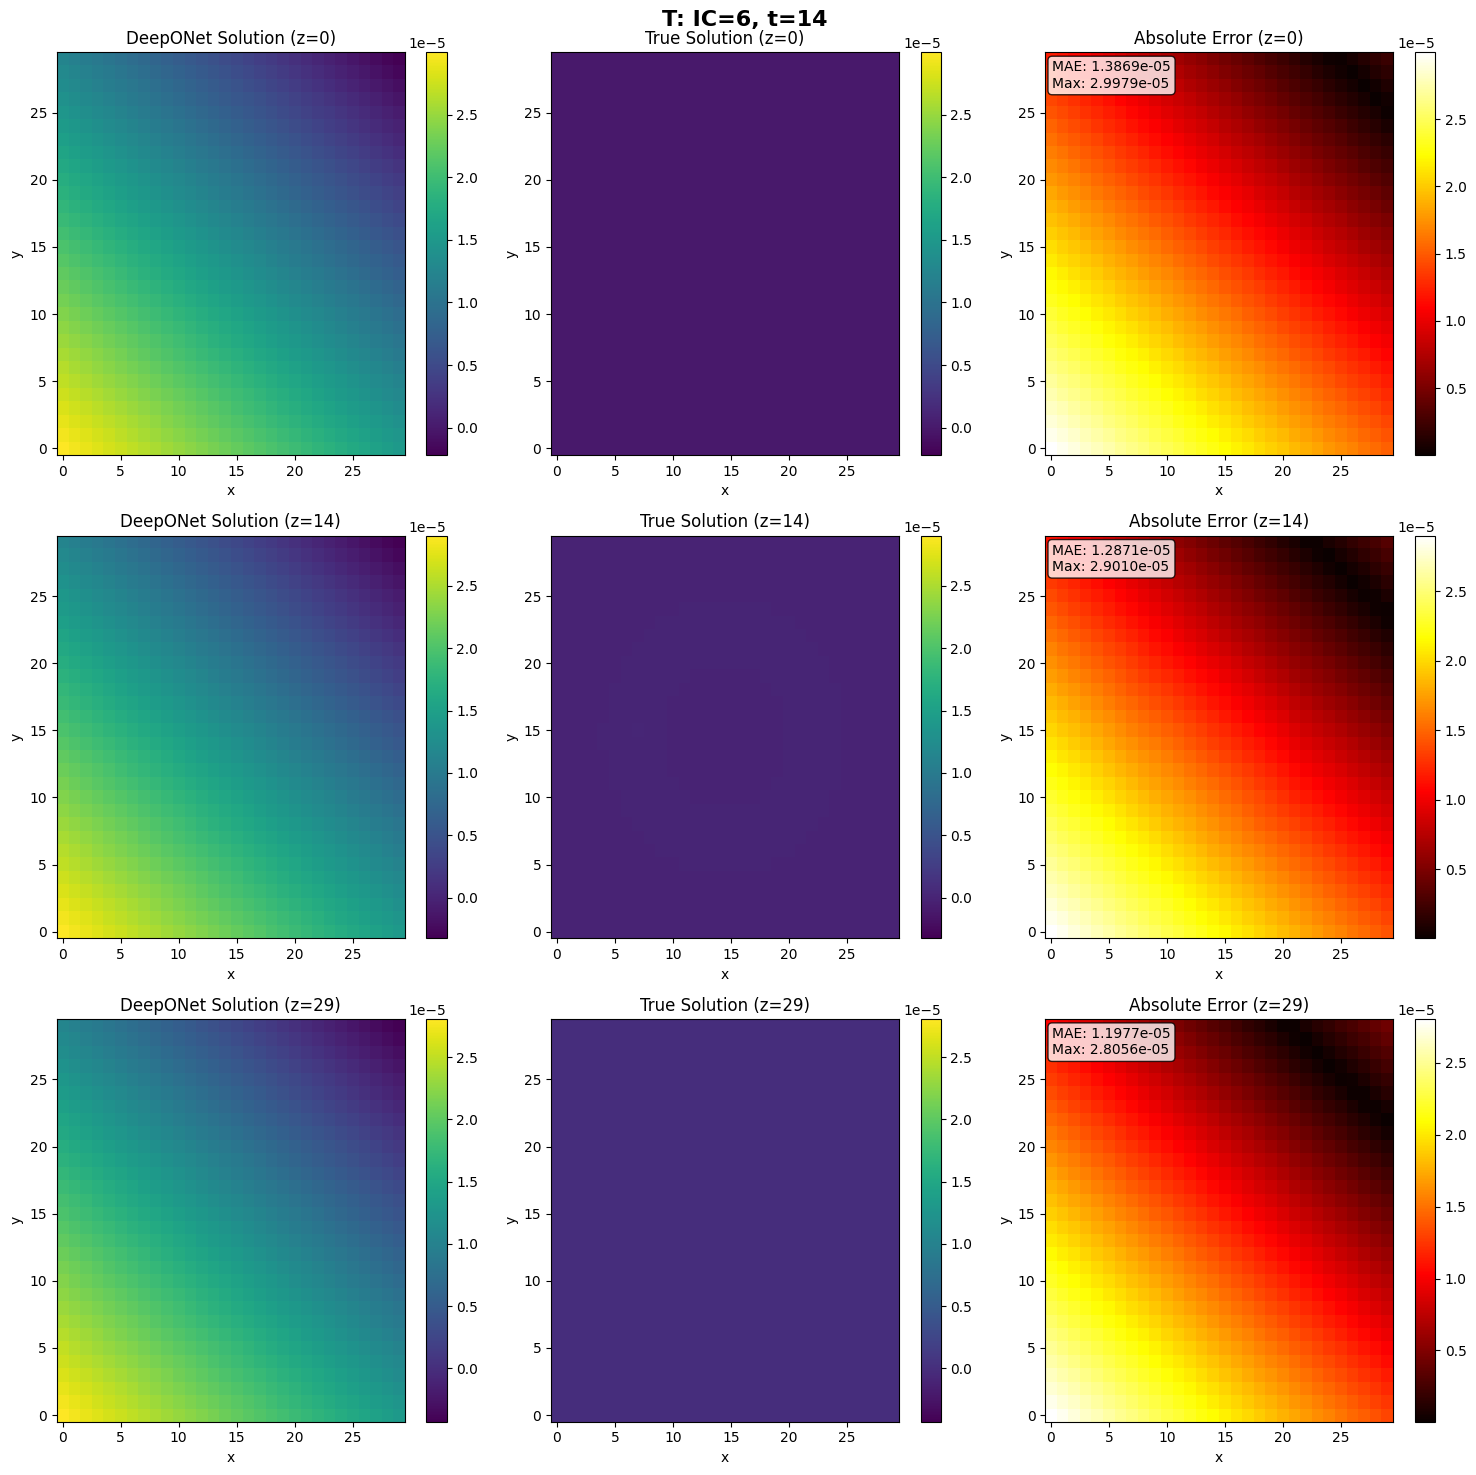

In [ ]:
visualize_multiple_z_slices(model, test, var_idx=1,mean=mean, std=std, ic_idx=6, time_idx=13,
                            z_slices=[0, 14, 29], device='cuda')

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_all_compartments_at_z(model, solutions, mean, std, ic_idx=2, time_idx=13, z_idx=15,
                                   device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Visualize all variables (N, T, I, U) for a single specific z-slice.
    Rows: Variables | Columns: Prediction, Ground Truth, Relative Error
    """
    # Get denormalized prediction for the whole field
    predicted_field = predict_full_field(model, solutions, ic_idx, time_idx,
                                         mean, std, device)
    ground_truth = solutions[ic_idx, time_idx, :, :, :, :]

    var_names = ['N (Neutrophils)', 'T (Tumor Cells)', 'I (Immune Cells)', 'U (Nutrients)']
    epsilon = 1e-10

    # Create plot: 4 rows (one for each variable), 3 columns
    fig, axes = plt.subplots(4, 3, figsize=(15, 18))

    fig.suptitle(f'Full Compartment Analysis: IC={ic_idx}, t={time_idx+1}, z-slice={z_idx}',
                 fontsize=18, fontweight='bold', y=1.02)

    for v_idx in range(4):
        # Extract slices for the current variable
        pred_slice = predicted_field[v_idx, :, :, z_idx]
        true_slice = ground_truth[v_idx, :, :, z_idx]

        # Calculate Relative Error (%)
        error_slice = (np.abs(pred_slice - true_slice) / (np.abs(true_slice) + epsilon)) * 100

        # Scale based on the data in this specific variable
        vmin = min(pred_slice.min(), true_slice.min())
        vmax = max(pred_slice.max(), true_slice.max())

        # --- 1. DeepONet Prediction ---
        im1 = axes[v_idx, 0].imshow(pred_slice.T, origin='lower', cmap='viridis',
                                    vmin=vmin, vmax=vmax, aspect='auto')
        axes[v_idx, 0].set_title(f'Pred: {var_names[v_idx]}')
        plt.colorbar(im1, ax=axes[v_idx, 0])

        # --- 2. Ground Truth ---
        im2 = axes[v_idx, 1].imshow(true_slice.T, origin='lower', cmap='viridis',
                                    vmin=vmin, vmax=vmax, aspect='auto')
        axes[v_idx, 1].set_title(f'Truth: {var_names[v_idx]}')
        plt.colorbar(im2, ax=axes[v_idx, 1])

        # --- 3. Relative Error Heatmap ---
        im3 = axes[v_idx, 2].imshow(error_slice.T, origin='lower', cmap='OrRd',
                                    aspect='auto')
        axes[v_idx, 2].set_title(f'Rel. Error %')
        plt.colorbar(im3, ax=axes[v_idx, 2], label='%')

        # Add Stats Box
        mean_rel = error_slice.mean()
        max_rel = error_slice.max()
        axes[v_idx, 2].text(0.02, 0.98, f'Mean: {mean_rel:.2f}%\nMax: {max_rel:.2f}%',
                            transform=axes[v_idx, 2].transAxes,
                            verticalalignment='top',
                            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                            fontsize=9)

    plt.tight_layout()
    plt.savefig(f'compartment_comparison_z{z_idx}_ic{ic_idx}.png', dpi=300, bbox_inches='tight')
    plt.show()

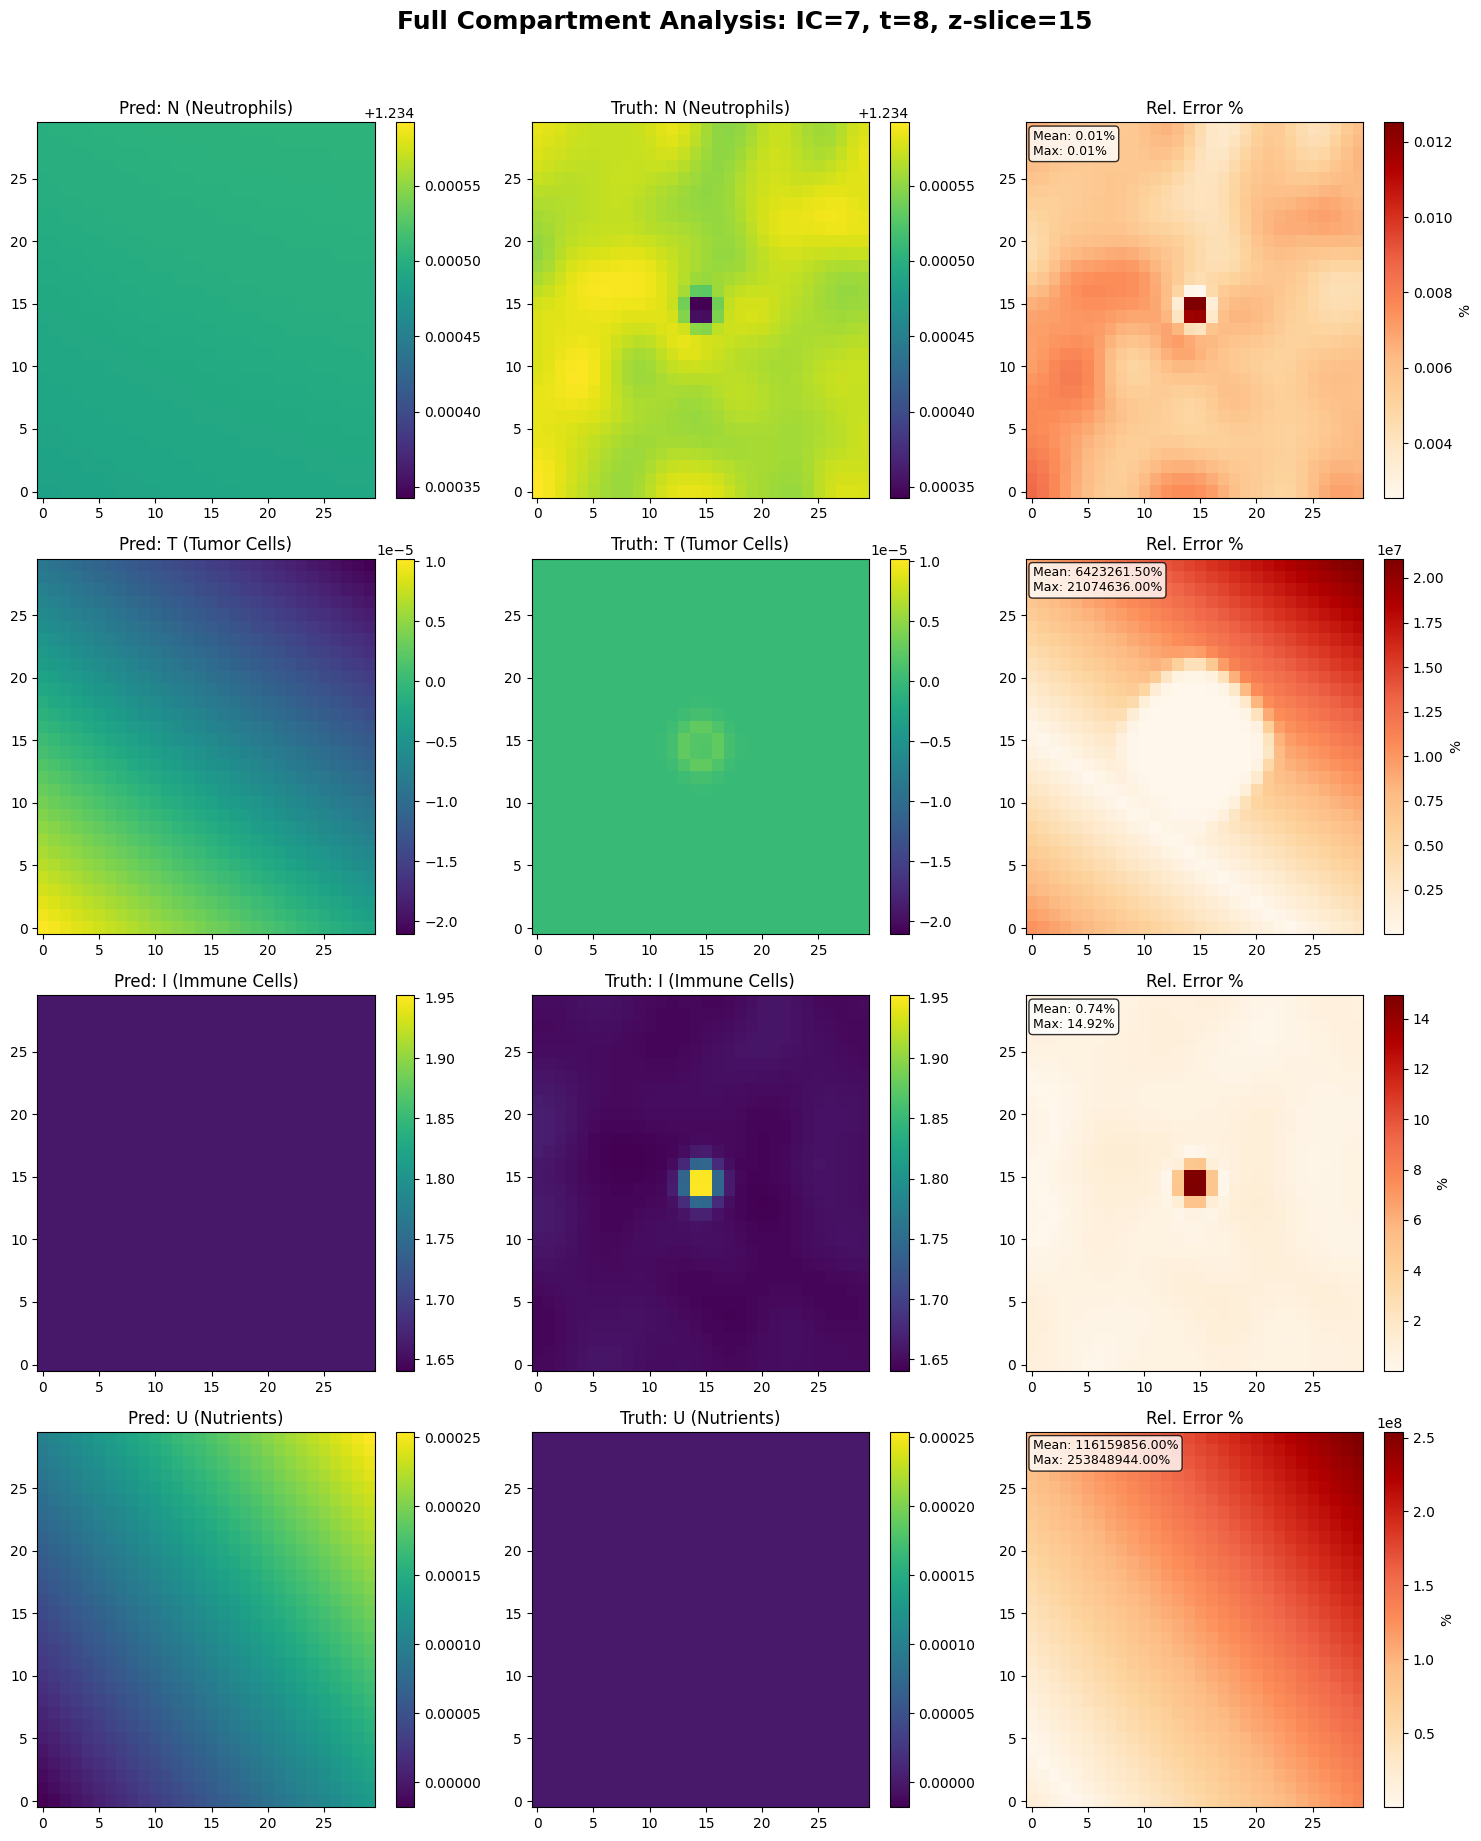

In [ ]:
visualize_all_compartments_at_z(model, test,mean=mean,std=std,ic_idx=7, time_idx=7,z_idx= 15, device='cuda')

In [ ]:
import time

times = []
for _ in range(100):
    start = time.time()
    predictions = predict_full_field(model, solutions, ic_idx=2, time_idx=13,
                                    mean=mean, std=std, device='cuda')
    end = time.time()
    times.append(end - start)

print(f"Average time: {sum(times)/len(times):.4f} seconds")
print(f"Min time: {min(times):.4f} seconds")
print(f"Max time: {max(times):.4f} seconds")

KeyboardInterrupt: 

In [ ]:
def get_best_U(pth_file, ics):
  checkpoint = torch.load(pth_file, map_location=torch.device('cpu'))
  mean = checkpoint['mean']
  std = checkpoint['std']

  model = DeepONet(
      hidden_dim=256,
      output_dim=4,
      number_of_layers=4,
      grid_channels=4,
      cnn_latent_dim=128
  ).to(device)
  model.load_state_dict(checkpoint['model_state_dict'])

  var_idx = 2
  time_idx = 13

  best_idx = None
  lowest = float('inf')

  for i in range(len(ics)):

    predicted_field = predict_full_field(model, ics[i], var_idx, time_idx,
                                          mean, std, device)
    np.mean(predicted_field)
    if np.mean(predicted_field) < lowest:
      lowest = np.mean(predicted_field)
      best_idx = i

  return best_idx

def predict_full_field(model, ic, var_idx, time_idx, mean, std,
                       device='cuda' if torch.cuda.is_available() else 'cpu',
                       batch_size=1000):
    model.eval()

    n_times, n_outputs, x_num, y_num, z_num = 15, 4, 30, 30, 30

    ic = torch.FloatTensor(ic).unsqueeze(0).to(device)

    t_normalized = time_idx / (n_times - 1)
    x_coords = torch.linspace(0, 1, x_num, device=device)
    y_coords = torch.linspace(0, 1, y_num, device=device)
    z_coords = torch.linspace(0, 1, z_num, device=device)

    X, Y, Z = torch.meshgrid(x_coords, y_coords, z_coords, indexing='ij')

    total_points = x_num * y_num * z_num
    trunk_coords = torch.stack([
        torch.full((total_points,), t_normalized, device=device),
        X.reshape(-1),
        Y.reshape(-1),
        Z.reshape(-1)
    ], dim=1)

    predictions_accumulator = []
    with torch.no_grad():
        for start_idx in range(0, total_points, batch_size):
            end_idx = min(start_idx + batch_size, total_points)
            batch_coords = trunk_coords[start_idx:end_idx]

            ic_batch = ic.repeat(batch_coords.shape[0], 1, 1, 1, 1)

            pred_batch = model(ic_batch, batch_coords)
            predictions_accumulator.append(pred_batch[:, var_idx])

        full_pred_flat = torch.cat(predictions_accumulator, dim=0)

    m = torch.as_tensor(mean, device=device).view(1, n_outputs)
    s = torch.as_tensor(std, device=device).view(1, n_outputs)
    full_pred_flat = full_pred_flat * s + m

    predictions = full_pred_flat.reshape(x_num, y_num, z_num, n_outputs)

    predictions = predictions.permute(3, 0, 1, 2)

    return predictions.cpu().numpy()

NameError: name 'torch' is not defined